### Importing Dependencies

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import pickle


### Loading Dataset

In [69]:

df = pd.read_csv("stroke_prediction_dataset.csv")
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,NaN,Rural,202.21,NaN,NaN,1
2,31112,Male,80.0,0,1,Yes,Private,NaN,105.92,32.5,never smoked,1
3,60182,Female,NaN,0,0,Yes,Private,Urban,NaN,34.4,smokes,1
4,1665,Female,NaN,1,0,Yes,Self-employed,Rural,NaN,24.0,NaN,1


In [70]:
df.sample(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5596,12689,Female,62.707586,0,0,Yes,Govt_job,Rural,204.851395,42.228070,NaN,1
685,28848,NaN,28.000000,0,0,No,Private,Urban,94.260000,23.700000,Unknown,0
5345,37132,NaN,82.286692,0,0,Yes,Govt_job,Urban,200.850040,29.211467,formerly smoked,1
3533,20655,NaN,16.000000,0,0,No,Private,Rural,94.960000,21.500000,never smoked,0
6545,17308,Female,NaN,1,0,Yes,Private,Urban,220.900365,29.915285,never smoked,1
1032,69622,Female,8.000000,0,0,No,children,NaN,65.320000,18.400000,Unknown,0
5731,30184,Male,82.213223,0,0,Yes,Private,Rural,86.396276,29.480564,formerly smoked,1
4452,27596,Female,82.000000,1,0,Yes,Private,Urban,115.710000,31.100000,formerly smoked,0
6031,35626,Male,80.535755,0,0,Yes,NaN,Urban,98.558906,33.403115,never smoked,1
1252,46576,Male,2.000000,0,0,No,children,NaN,68.520000,20.800000,NaN,0


In [71]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
6837,60182,Female,48.593665,0,0,Yes,NaN,Urban,NaN,34.187546,smokes,1
6838,3355,NaN,64.000000,0,0,Yes,Private,Urban,82.340000,31.900000,NaN,0
6839,35626,Male,80.535755,0,0,Yes,NaN,Urban,98.558906,33.403115,never smoked,1
6840,51109,Female,6.000000,0,0,No,children,NaN,119.880000,NaN,NaN,0
6841,52173,Male,38.000000,0,0,No,NaN,Urban,74.090000,39.600000,never smoked,0


### Data Overview

In [72]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6842 entries, 0 to 6841
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 6842 non-null   int64  
 1   gender             5674 non-null   object 
 2   age                5749 non-null   float64
 3   hypertension       6842 non-null   int64  
 4   heart_disease      6842 non-null   int64  
 5   ever_married       6842 non-null   object 
 6   work_type          5617 non-null   object 
 7   Residence_type     5821 non-null   object 
 8   avg_glucose_level  5473 non-null   float64
 9   bmi                4964 non-null   float64
 10  smoking_status     5405 non-null   object 
 11  stroke             6842 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 641.6+ KB


In [73]:
df.shape

(6842, 12)

In [74]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,6842.000000,5749.000000,6842.000000,6842.000000,5473.000000,4964.000000,6842.000000
mean,36513.900614,48.977120,0.134902,0.088571,111.665622,29.183543,0.275650
std,21388.174883,23.283402,0.341644,0.284144,50.331767,7.564271,0.446874
min,67.000000,0.080000,0.000000,0.000000,54.673621,10.300000,0.000000
25%,17298.250000,31.000000,0.000000,0.000000,77.650000,24.100000,0.000000
50%,36822.500000,52.000000,0.000000,0.000000,93.670000,28.400000,0.000000
75%,54870.500000,69.000000,0.000000,0.000000,122.260000,33.100000,1.000000
max,72940.000000,82.931979,1.000000,1.000000,272.360845,97.600000,1.000000


In [75]:
df.isnull().sum()

id                      0
gender               1168
age                  1093
hypertension            0
heart_disease           0
ever_married            0
work_type            1225
Residence_type       1021
avg_glucose_level    1369
bmi                  1878
smoking_status       1437
stroke                  0
dtype: int64

In [76]:
df.duplicated().sum()

np.int64(134)

In [77]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [78]:
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(numerical_cols)
print(categorical_cols)

Index(['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level',
       'bmi', 'stroke'],
      dtype='object')
Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')


### Data Cleaning

In [79]:
df = df.drop_duplicates()

In [80]:
df.shape

(6708, 12)

In [81]:
df.duplicated().sum()

np.int64(0)

In [82]:
df.isnull().sum()

id                      0
gender               1140
age                  1073
hypertension            0
heart_disease           0
ever_married            0
work_type            1207
Residence_type       1006
avg_glucose_level    1341
bmi                  1840
smoking_status       1408
stroke                  0
dtype: int64

In [83]:
mean_values=df[numerical_cols].mean()
median_values=df[numerical_cols].median()
print(mean_values)
print(median_values)

id                   36541.274747
age                     49.012119
hypertension             0.134914
heart_disease            0.089147
avg_glucose_level      111.649313
bmi                     29.167143
stroke                   0.275343
dtype: float64
id                   36841.000000
age                     52.408807
hypertension             0.000000
heart_disease            0.000000
avg_glucose_level       93.640000
bmi                     28.400000
stroke                   0.000000
dtype: float64


In [84]:
df['avg_glucose_level'].fillna(df['avg_glucose_level'].median(), inplace=True)
df['bmi'].fillna(df['bmi'].mean(), inplace=True)
df['age'].fillna(df['age'].ffill(), inplace=True)
df['gender'].fillna(df['gender'].bfill(), inplace=True)

In [85]:
df.isnull().sum()

id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type            1207
Residence_type       1006
avg_glucose_level       0
bmi                     0
smoking_status       1408
stroke                  0
dtype: int64

In [86]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
6703,19773,Female,52.408807,0,0,Yes,Private,Rural,97.235130,26.373256,NaN,1
6704,24977,Female,70.931357,1,0,Yes,Private,Rural,93.640000,23.058278,NaN,1
6705,48796,Female,70.931357,0,0,Yes,Govt_job,Urban,93.640000,29.167143,Unknown,1
6706,20387,Female,70.931357,1,0,Yes,Self-employed,Rural,204.699758,29.167143,never smoked,1
6707,33454,Female,63.930508,0,0,Yes,Govt_job,Rural,104.877329,23.941512,Unknown,1


In [87]:
df.drop(columns=['id'], axis=1, inplace=True)

In [88]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.000000,0,1,Yes,Private,Urban,228.690000,36.600000,formerly smoked,1
1,Female,61.000000,0,0,Yes,NaN,Rural,202.210000,29.167143,NaN,1
2,Male,80.000000,0,1,Yes,Private,NaN,105.920000,32.500000,never smoked,1
3,Female,80.000000,0,0,Yes,Private,Urban,93.640000,34.400000,smokes,1
4,Female,80.000000,1,0,Yes,Self-employed,Rural,93.640000,24.000000,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
6703,Female,52.408807,0,0,Yes,Private,Rural,97.235130,26.373256,NaN,1
6704,Female,70.931357,1,0,Yes,Private,Rural,93.640000,23.058278,NaN,1
6705,Female,70.931357,0,0,Yes,Govt_job,Urban,93.640000,29.167143,Unknown,1
6706,Female,70.931357,1,0,Yes,Self-employed,Rural,204.699758,29.167143,never smoked,1


In [89]:
df['bmi'] = df['bmi'].round(2)
df['avg_glucose_level'] = df['avg_glucose_level'].round(2)
df['age'] = df['age'].astype(int)

In [90]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.60,formerly smoked,1
1,Female,61,0,0,Yes,NaN,Rural,202.21,29.17,NaN,1
2,Male,80,0,1,Yes,Private,NaN,105.92,32.50,never smoked,1
3,Female,80,0,0,Yes,Private,Urban,93.64,34.40,smokes,1
4,Female,80,1,0,Yes,Self-employed,Rural,93.64,24.00,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
6703,Female,52,0,0,Yes,Private,Rural,97.24,26.37,NaN,1
6704,Female,70,1,0,Yes,Private,Rural,93.64,23.06,NaN,1
6705,Female,70,0,0,Yes,Govt_job,Urban,93.64,29.17,Unknown,1
6706,Female,70,1,0,Yes,Self-employed,Rural,204.70,29.17,never smoked,1


In [91]:
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

In [92]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [93]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.60,formerly smoked,1
1,Female,61,0,0,Yes,Private,Rural,202.21,29.17,never smoked,1
2,Male,80,0,1,Yes,Private,Urban,105.92,32.50,never smoked,1
3,Female,80,0,0,Yes,Private,Urban,93.64,34.40,smokes,1
4,Female,80,1,0,Yes,Self-employed,Rural,93.64,24.00,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
6703,Female,52,0,0,Yes,Private,Rural,97.24,26.37,never smoked,1
6704,Female,70,1,0,Yes,Private,Rural,93.64,23.06,never smoked,1
6705,Female,70,0,0,Yes,Govt_job,Urban,93.64,29.17,Unknown,1
6706,Female,70,1,0,Yes,Self-employed,Rural,204.70,29.17,never smoked,1


### Exploratory Data Analysis (EDA)

In [94]:
for col in df.columns:
    if col not in ['age', 'bmi', 'avg_glucose_level']:
        print(f"Unique values in column '{col}':")
        print(df[col].unique())

Unique values in column 'gender':
['Male' 'Female' 'Other']
Unique values in column 'hypertension':
[0 1]
Unique values in column 'heart_disease':
[1 0]
Unique values in column 'ever_married':
['Yes' 'No']
Unique values in column 'work_type':
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Unique values in column 'Residence_type':
['Urban' 'Rural']
Unique values in column 'smoking_status':
['formerly smoked' 'never smoked' 'smokes' 'Unknown']
Unique values in column 'stroke':
[1 0]


In [95]:
df.shape

(6708, 11)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6708 entries, 0 to 6707
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             6708 non-null   object 
 1   age                6708 non-null   int64  
 2   hypertension       6708 non-null   int64  
 3   heart_disease      6708 non-null   int64  
 4   ever_married       6708 non-null   object 
 5   work_type          6708 non-null   object 
 6   Residence_type     6708 non-null   object 
 7   avg_glucose_level  6708 non-null   float64
 8   bmi                6708 non-null   float64
 9   smoking_status     6708 non-null   object 
 10  stroke             6708 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 628.9+ KB


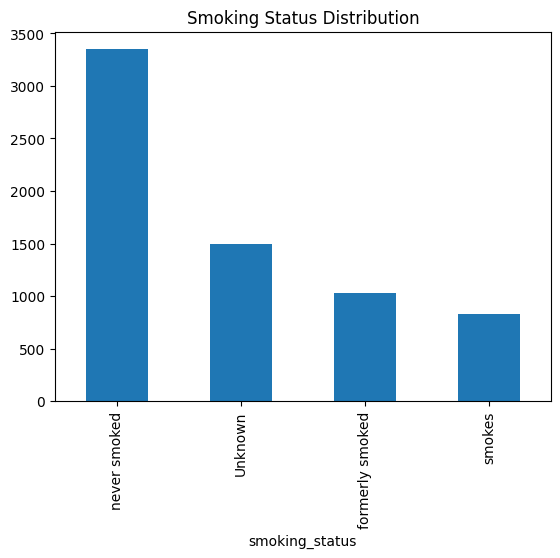

In [97]:
df['smoking_status'].value_counts().plot(kind='bar')
plt.title("Smoking Status Distribution")
plt.show()

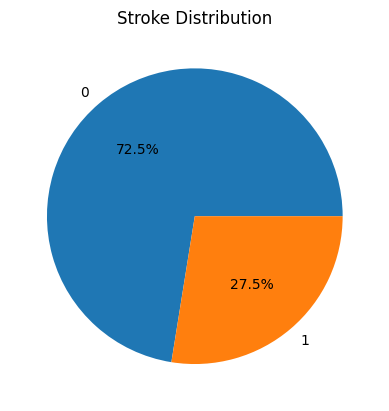

In [98]:
df['stroke'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Stroke Distribution")
plt.ylabel('')
plt.show()

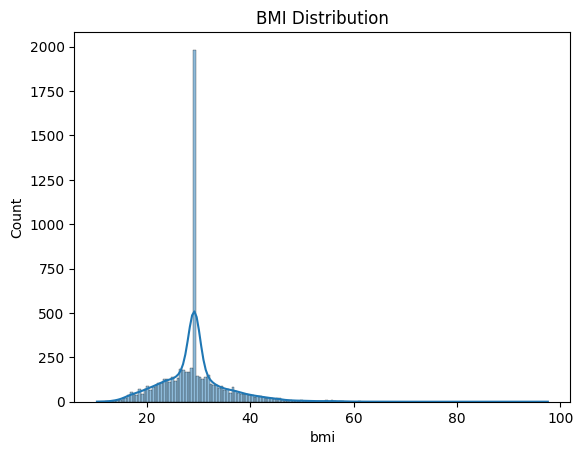

In [99]:

sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()


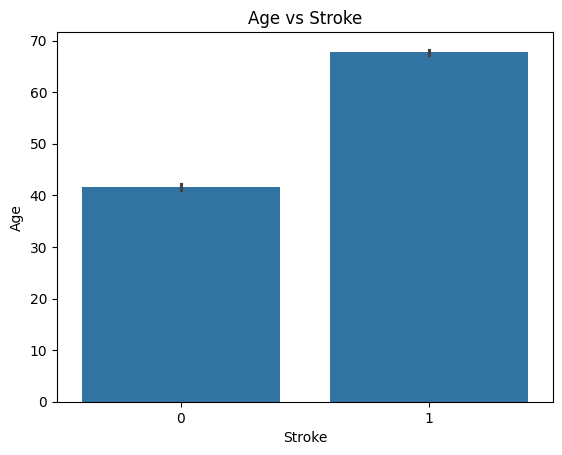

In [100]:
sns.barplot(x='stroke', y='age', data=df)
plt.title("Age vs Stroke")
plt.xlabel("Stroke")
plt.ylabel("Age")
plt.show()

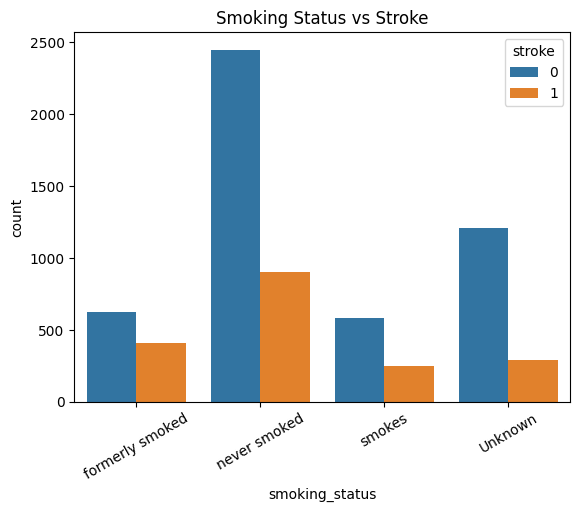

In [101]:
sns.countplot(x='smoking_status', hue='stroke', data=df)
plt.title("Smoking Status vs Stroke")
plt.xticks(rotation=30)
plt.show()

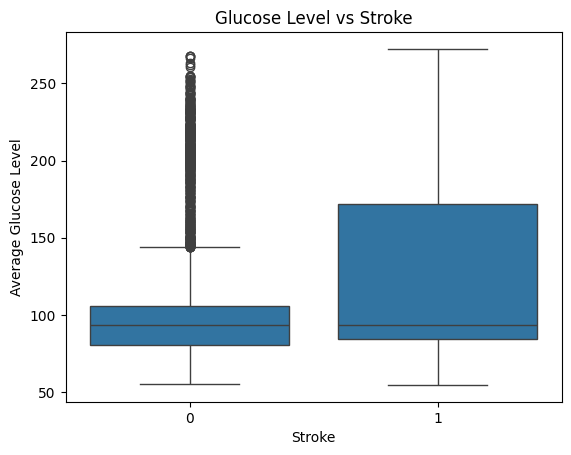

In [102]:
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)
plt.title("Glucose Level vs Stroke")
plt.xlabel("Stroke")
plt.ylabel("Average Glucose Level")
plt.show()

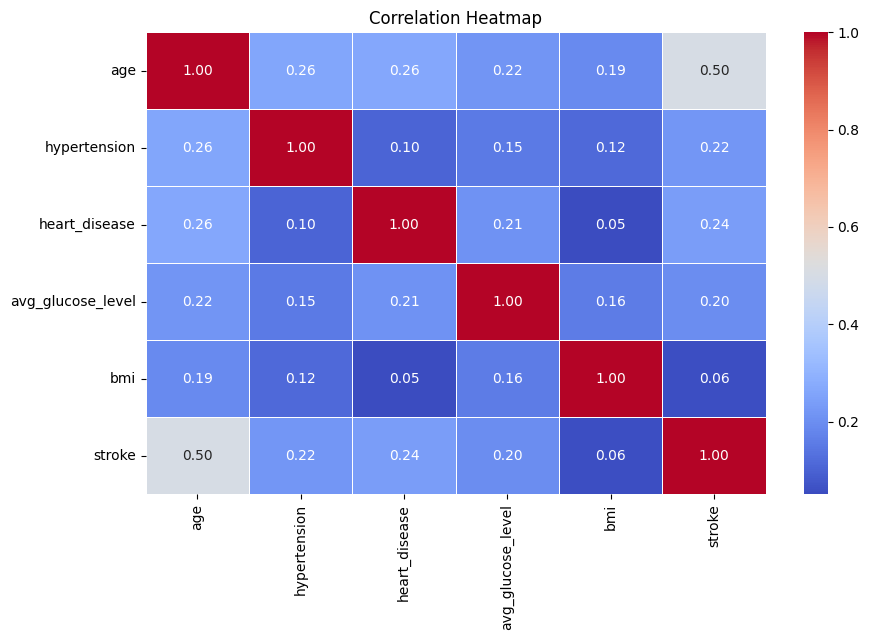

In [103]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

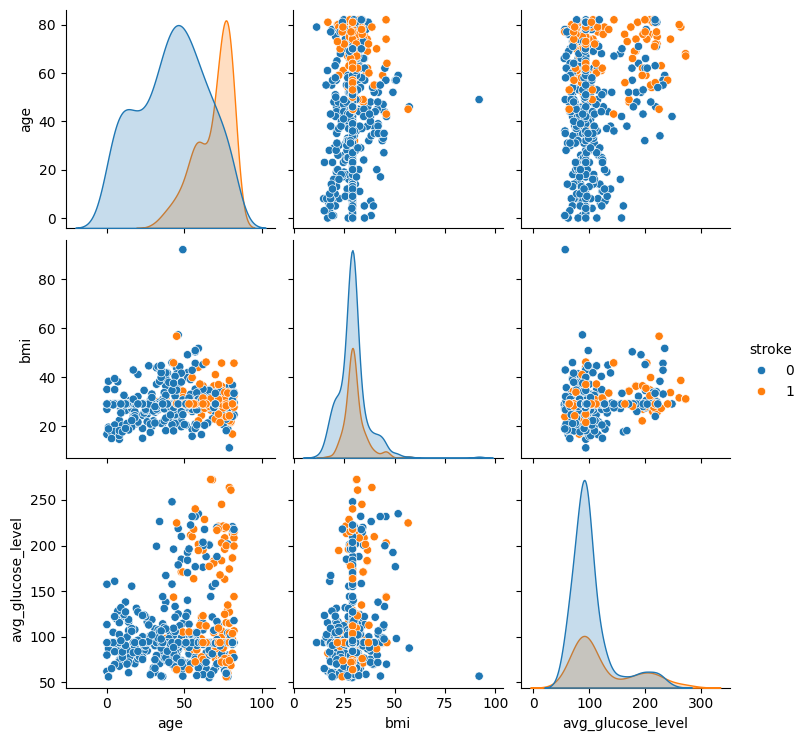

In [104]:
sample_df = df.sample(500, random_state=42)
sns.pairplot(sample_df, vars=['age', 'bmi', 'avg_glucose_level'], hue='stroke', diag_kind='kde')


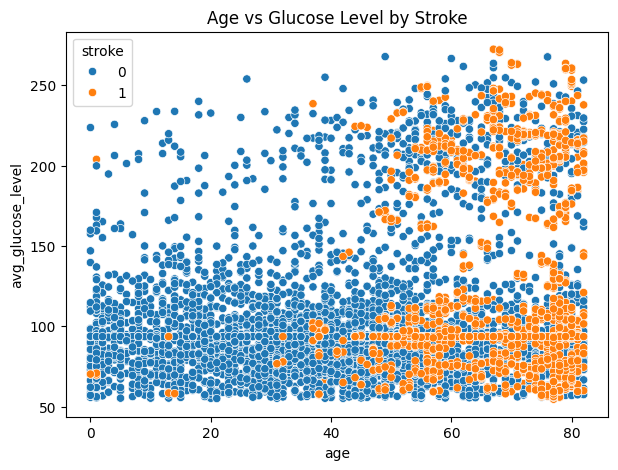

In [105]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='age', y='avg_glucose_level', hue='stroke', data=df)
plt.title("Age vs Glucose Level by Stroke")
plt.show()

### Feature Engineering

In [106]:
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67,0,1,1,2,1,228.69,36.60,1,1
1,0,61,0,0,1,2,0,202.21,29.17,2,1
2,1,80,0,1,1,2,1,105.92,32.50,2,1
3,0,80,0,0,1,2,1,93.64,34.40,3,1
4,0,80,1,0,1,3,0,93.64,24.00,2,1
...,...,...,...,...,...,...,...,...,...,...,...
6703,0,52,0,0,1,2,0,97.24,26.37,2,1
6704,0,70,1,0,1,2,0,93.64,23.06,2,1
6705,0,70,0,0,1,0,1,93.64,29.17,0,1
6706,0,70,1,0,1,3,0,204.70,29.17,2,1


In [107]:
X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [108]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Creation

In [109]:
lrm = LogisticRegression(max_iter=1000)
lrm.fit(X_train_scaled, y_train)
y_pred_lrm = lrm.predict(X_test_scaled)
print("Accuracy:- ",lrm.score(X_test_scaled,y_test)*100)

Accuracy:-  79.80625931445604


In [110]:

rfm = RandomForestClassifier(n_estimators=200, random_state=42)
rfm.fit(X_train_scaled, y_train)
y_pred_rfm = rfm.predict(X_test_scaled)
print("Accuracy:- ", rfm.score(X_test_scaled,y_test)*100)


Accuracy:-  89.04619970193741


In [111]:
dtm=DecisionTreeClassifier()
dtm.fit(X_train_scaled,y_train)
y_pred_dtm = dtm.predict(X_test_scaled)
print("Accuracy:- ", dtm.score(X_test_scaled,y_test)*100)

Accuracy:-  84.79880774962743


In [112]:
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
print("Accuracy:- ", xgb.score(X_test_scaled,y_test)*100)

Accuracy:-  88.15201192250373


In [113]:
models = {
    "Logistic Regression": lrm,
    "Random Forest": rfm,
    "Decision Tree": dtm,
    "XGBoost": xgb
}
results = []

for name,model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })
    
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.798063   0.652308  0.572973  0.610072
1        Random Forest  0.890462   0.792651  0.816216  0.804261
2        Decision Tree  0.847988   0.707500  0.764865  0.735065
3              XGBoost  0.881520   0.789041  0.778378  0.783673


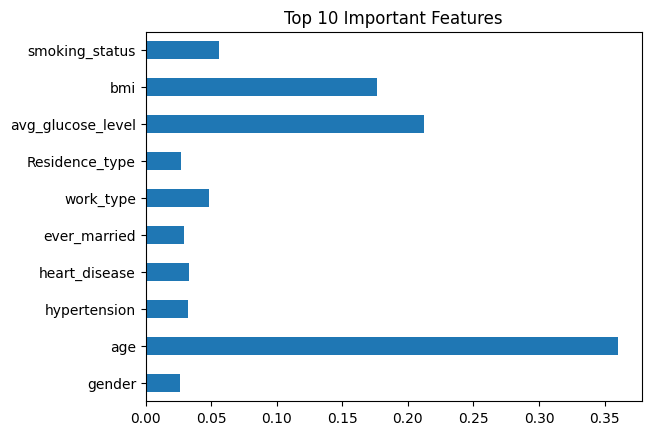

In [114]:
feature_importance = pd.Series(rfm.feature_importances_, index=X.columns)
feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

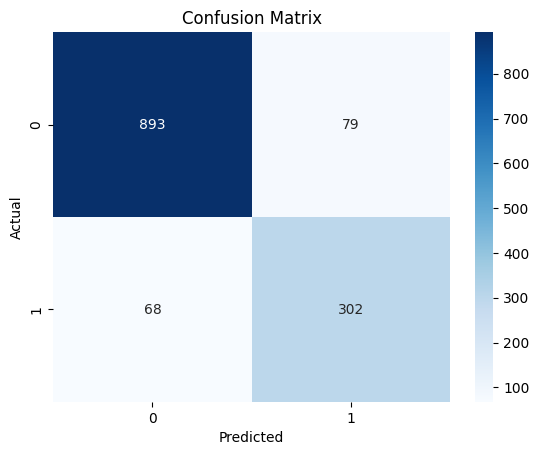

In [115]:
cm = confusion_matrix(y_test, y_pred_rfm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [116]:
with open('model.sav', 'wb') as f:
    pickle.dump(rfm, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)